# Validation

**INPUT**: Tokenized train, validation, test corpora

**OUTPUT**: Model parameter recommendations

| Step | Decision | Status | Comment |
|------|----------|--------|---------|
| Tokenized sequence length distribution | - | Pending | - |
| Vocabulary coverage analysis | - | Pending | - |

## Input & Setup

### Imports

In [2]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import sys
from pathlib import Path

project_root = Path().resolve().parent
src = project_root / "src"
if str(src) not in sys.path:
    sys.path.insert(0, str(src))

from config.config import PATHS

### Load Pickles Into Dictionary

In [3]:
paths = {
    "train": PATHS.train_pieces,
    "val": PATHS.validation_pieces,
    "test": PATHS.test_pieces
}

tokenized_data = {}
for split, path in paths.items():
    with open(path, "rb") as f:
        tokenized_data[split] = pickle.load(f)
    print(f"{split} split: {len(tokenized_data[split])} sequences")

train split: 17387 sequences
val split: 5975 sequences
test split: 6043 sequences


## Steps

### Tokenized Sequence Length Distribution

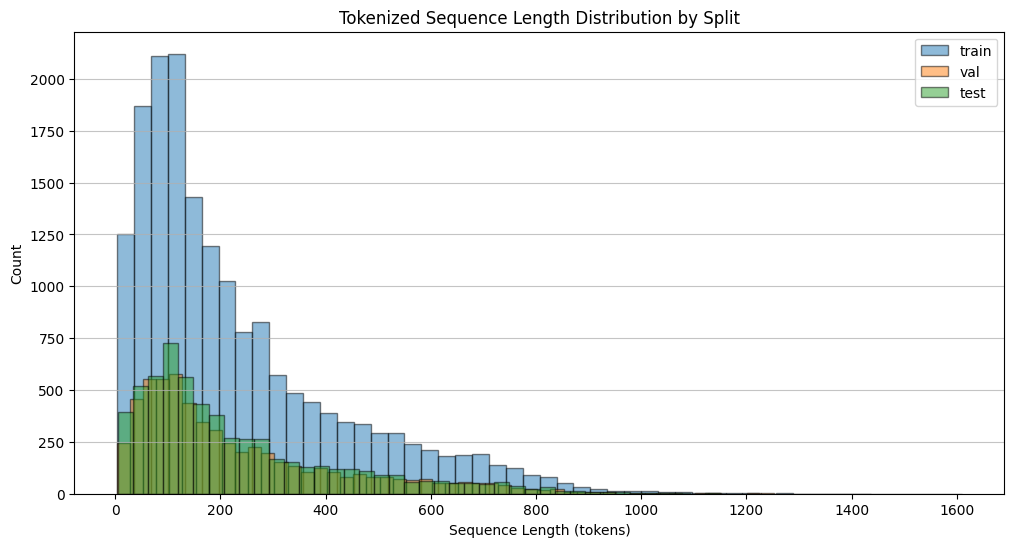

train — mean: 231.73, median: 162.0, min: 4, max: 1610
val — mean: 236.98, median: 166.0, min: 3, max: 1252
test — mean: 234.37, median: 165.0, min: 6, max: 1436


In [4]:
plt.figure(figsize=(12,6))

bins = 50
alpha = 0.5
for split, data in tokenized_data.items():
    lengths = [len(seq) for seq in data]
    plt.hist(lengths, bins=bins, alpha=alpha, label=split, edgecolor='black')

plt.title("Tokenized Sequence Length Distribution by Split")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Count")
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.savefig("tokenized_sequence_length_distribution_by_split.png", dpi=300, bbox_inches="tight")
plt.show()

for split, data in tokenized_data.items():
    lengths = [len(seq) for seq in data]
    print(f"{split} — mean: {pd.Series(lengths).mean():.2f}, median: {pd.Series(lengths).median()}, min: {min(lengths)}, max: {max(lengths)}")

### Vocabulary Coverage

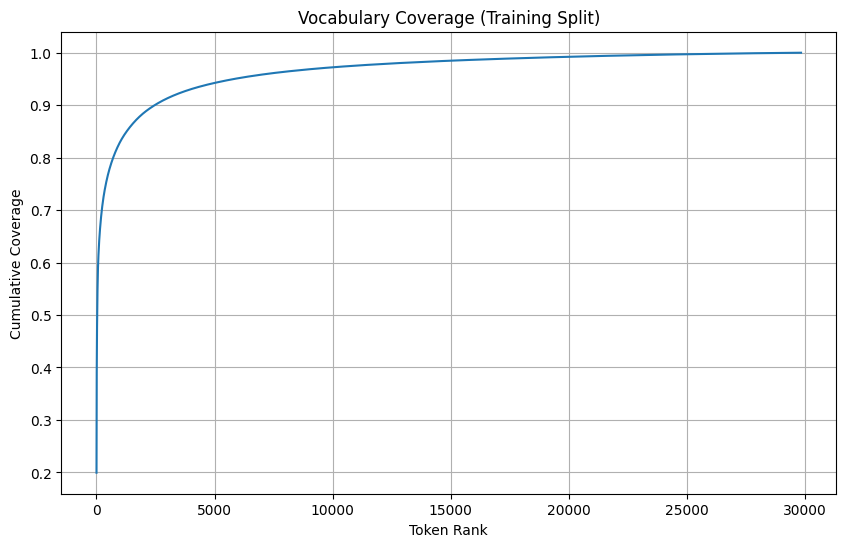

Top 30 tokens in training set:
       token   count  cum_freq
0          ▁  803357  0.199389
52     <NUM>  129549  0.231542
62         ,  101526  0.256741
2          :   81991  0.277090
16         s   78560  0.296589
40     <URL>   76343  0.315536
143     ▁the   71863  0.333372
25       ▁to   64843  0.349466
49         -   57554  0.363751
19         .   56858  0.377863
79         /   51109  0.390548
119     ▁and   42114  0.401000
209      ▁of   34954  0.409675
138       ▁a   34157  0.418153
35      ▁you   32594  0.426243
117     ▁for   28905  0.433417
146      ▁in   26187  0.439916
8        ing   23331  0.445707
183       ed   23175  0.451459
1    subject   23094  0.457191
137      ▁is   21884  0.462622
181    ▁your   20378  0.467680
152        d   19660  0.472559
259       ▁i   19082  0.477295
107      ▁on   18590  0.481909
375        '   17634  0.486286
103    ▁this   17562  0.490645
34         !   17146  0.494900
315      ▁be   15592  0.498770
18         y   14792  0.502441


In [ ]:
# Flatten training tokens
train_tokens = [token for seq in tokenized_data["train"] for token in seq]

# Count token frequencies
train_token_counts = Counter(train_tokens)
total_train_tokens = len(train_tokens)

# Create DataFrame for coverage
vocab_df = pd.DataFrame(train_token_counts.items(), columns=["token", "count"]).sort_values(by="count", ascending=False)
vocab_df["cum_freq"] = vocab_df["count"].cumsum() / total_train_tokens

# Plot cumulative coverage
plt.figure(figsize=(10,6))
plt.plot(range(1, len(vocab_df)+1), vocab_df["cum_freq"])
plt.title("Vocabulary Coverage (Training Split)")
plt.xlabel("Token Rank")
plt.ylabel("Cumulative Coverage")
plt.grid(True)
plt.savefig("vocab_coverage_traning_tokenized.png", dpi=300, bbox_inches="tight")

plt.show()

print("Top 30 tokens in training set:")
print(vocab_df.head(30))